In [77]:
import pandas as pd

prediction = pd.read_csv('..//output//output10.csv')
reality = pd.read_csv('..//Data//summerOly_medal_counts.csv')

prediction['Total_Weighted_Medals'] = prediction['gold']  + prediction['silver'] * 0.6122 + prediction['bronze'] * 0.3125

prediction_2024 = prediction[prediction['year'] == 2024]
prediction_2028 = prediction[prediction['year'] == 2028]

reality_2024 = reality[reality['Year'] == 2024]
reality_2024.drop(['Rank','Host'],axis=1,inplace=True)


reality_2024.rename(columns={'NOC': 'country', 'Gold': 'gold', 'Silver': 'silver', 'Bronze': 'bronze' , 'Year' : 'year'}, inplace=True)
print(prediction_2024.columns)
print(prediction_2028.columns)
print(reality_2024.columns)

 

Index(['country', 'year', 'gold', 'silver', 'bronze', 'Total_Weighted_Medals'], dtype='object')
Index(['country', 'year', 'gold', 'silver', 'bronze', 'Total_Weighted_Medals'], dtype='object')
Index(['country', 'gold', 'silver', 'bronze', 'Total', 'year',
       'Total_Weighted_Medals'],
      dtype='object')


C:\Users\lenovo\AppData\Local\Temp\ipykernel_24688\2290826285.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reality_2024.drop(['Rank','Host'],axis=1,inplace=True)
C:\Users\lenovo\AppData\Local\Temp\ipykernel_24688\2290826285.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reality_2024.rename(columns={'NOC': 'country', 'Gold': 'gold', 'Silver': 'silver', 'Bronze': 'bronze' , 'Year' : 'year'}, inplace=True)


C:\Users\lenovo\AppData\Local\Temp\ipykernel_24688\3673624727.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_2028['total_medals'] = prediction_2028['gold'] + prediction_2028['silver'] + prediction_2028['bronze']


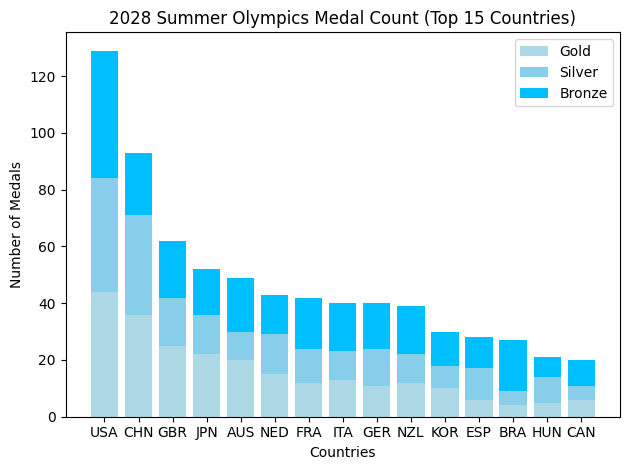

In [78]:
import pandas as pd
import matplotlib.pyplot as plt

NOC = ['USA','CHN','GBR','JPN','AUS','NED','FRA','ITA','GER','NZL','KOR','ESP','BRA','HUN','CAN']

# 确保所需列存在
prediction_2028['total_medals'] = prediction_2028['gold'] + prediction_2028['silver'] + prediction_2028['bronze']

# 选择总奖牌数排名前15的国家
top_15_2028 = prediction_2028.nlargest(15, 'total_medals')

top_15_2028['country'] = NOC

# 提取柱状图所需数据
countries = top_15_2028['country']
gold = top_15_2028['gold']
silver = top_15_2028['silver']
bronze = top_15_2028['bronze']

# 绘制堆叠柱状图
bar_width = 0.8

plt.bar(countries, gold, color='lightblue', label='Gold', width=bar_width)
plt.bar(countries, silver, color='skyblue', label='Silver', bottom=gold, width=bar_width)
plt.bar(countries, bronze, color='deepskyblue', label='Bronze', bottom=gold + silver, width=bar_width)

# 添加标签和图例
plt.xlabel('Countries')
plt.ylabel('Number of Medals')
plt.title('2028 Summer Olympics Medal Count (Top 15 Countries)')    
plt.legend()

# 显示图表
plt.xticks()
plt.tight_layout()
plt.show()


         country  Total_Weighted_Medals_real  Total_Weighted_Medals_pred
0  United States                     80.0618                     72.8630
1          China                     64.0294                     65.8404
2         France                     38.7922                     30.6333
3  Great Britain                     36.5309                     31.7071
4      Australia                     34.6318                     35.5821
5          Japan                     31.4089                     28.8720
6          Italy                     24.6461                     27.0467
7    Netherlands                     23.0354                     24.9104
8        Germany                     22.4586                     22.8848
9    South Korea                     21.6348                     15.5610


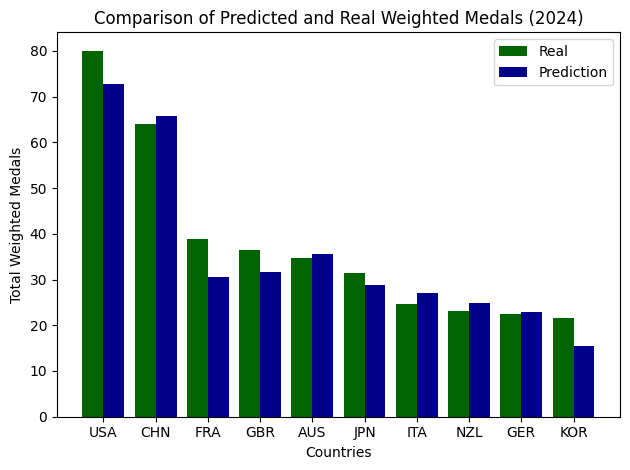

In [79]:
# 按加权总奖牌数排序，选取前 10 名国家
top_10_reality = reality_2024.nlargest(10, 'Total_Weighted_Medals')
top_10_countries = top_10_reality['country']

# 筛选预测数据中对应国家的记录
top_10_prediction = prediction_2024[prediction_2024['country'].isin(top_10_countries)]

# 合并预测值和真实值
comparison = pd.merge(
    top_10_reality[['country', 'Total_Weighted_Medals']], 
    top_10_prediction[['country', 'Total_Weighted_Medals']],
    on='country',
    suffixes=('_real', '_pred')
)
print(comparison)

NOC = ['USA','CHN','FRA','GBR','AUS','JPN','ITA','NZL','GER','KOR']
comparison['country'] = NOC
# 绘制对比图
x = range(len(comparison))  # 国家数量
width = 0.4

plt.bar(x, comparison['Total_Weighted_Medals_real'], width=width, label='Real', color='darkgreen', align='center')
plt.bar([i + width for i in x], comparison['Total_Weighted_Medals_pred'], width=width, label='Prediction', color='darkblue', align='center')

# 添加标签和标题
plt.xlabel('Countries')
plt.ylabel('Total Weighted Medals')
plt.title('Comparison of Predicted and Real Weighted Medals (2024)')
plt.xticks([i + width / 2 for i in x], comparison['country'])
plt.legend()

# 显示图表
plt.tight_layout()
plt.show()

In [80]:
# 合并 2024 和 2028 数据
comparison = pd.merge(
    reality_2024[['country', 'Total_Weighted_Medals']].rename(columns={'Total_Weighted_Medals': 'Total_Weighted_Medals_2024'}),
    prediction_2028[['country', 'Total_Weighted_Medals']].rename(columns={'Total_Weighted_Medals': 'Total_Weighted_Medals_2028'}),
    on='country'
)

# 计算变化
comparison['change'] = comparison['Total_Weighted_Medals_2028'] - comparison['Total_Weighted_Medals_2024']

# 获取增长和减少最多的国家
top_20_increase = comparison.nlargest(20, 'change')
top_20_decrease = comparison.nsmallest(20, 'change')

NOC1 = ['NZL','ESP','GBR','NED','EGY','POL','JPN','BEL','ARG','POR','BOT','MAR','USA','CUB','BRN','BRA','CHI','SWE','DEN','ECU']
NOC2 = ['FRA','UZB','IRI','CAN','KOR','AUS','KEN','LTU','THA','ROU','TUR','BUL','MEX','PRK','GRN','PAN','IRL','KGZ','KOS','CPV']
top_20_increase['country'] = NOC1
top_20_decrease['country'] = NOC2

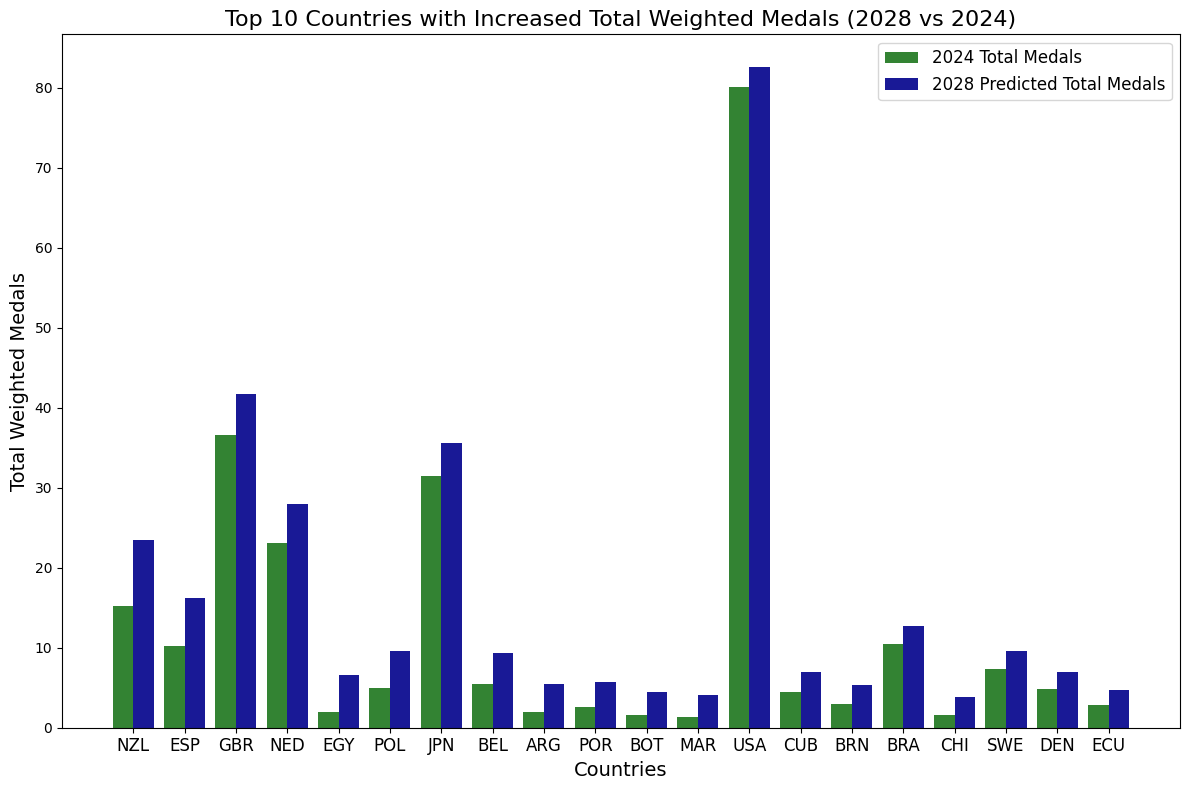

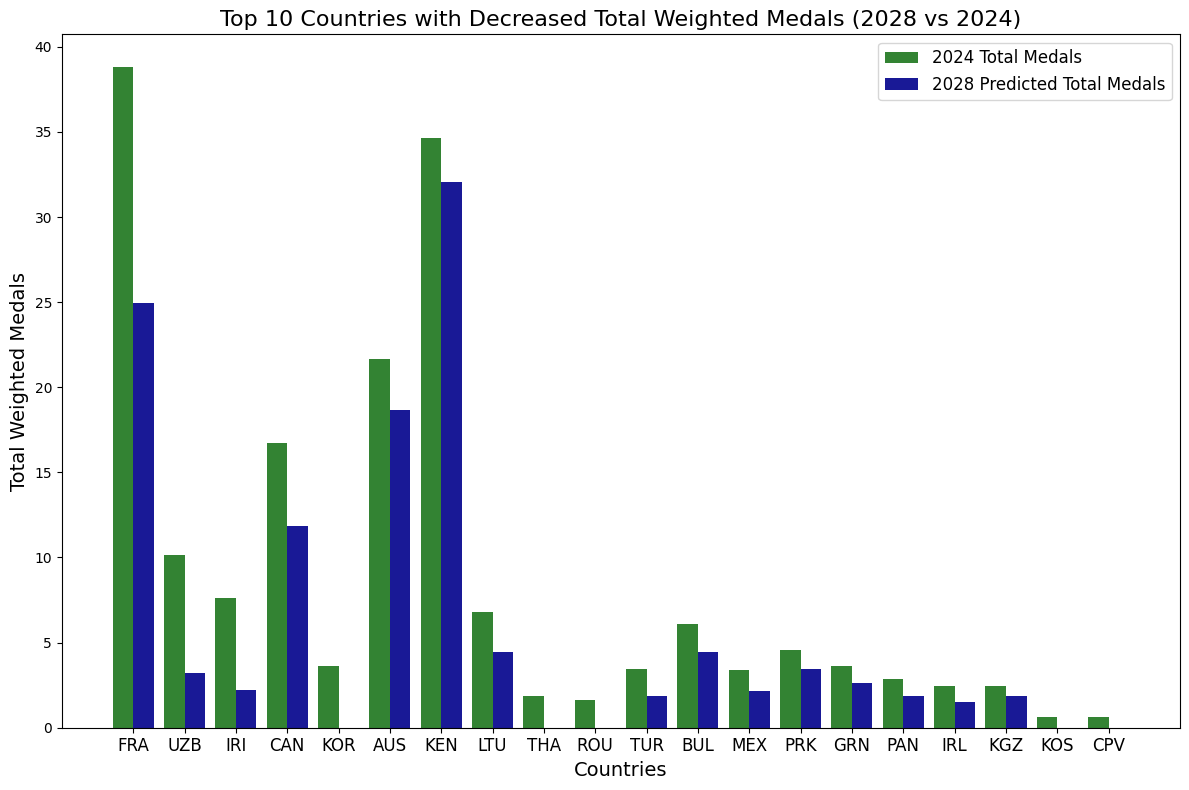

In [81]:
import matplotlib.pyplot as plt
import numpy as np

# 绘制增长最多的 20 个国家的图
x_increase = np.arange(len(top_20_increase))  # 使用 NumPy 创建 x 坐标

plt.figure(figsize=(12, 8))

# 绘制 2024 年真实数据柱子（稍窄，稍微向左偏移）
plt.bar(x_increase - 0.2, top_20_increase['Total_Weighted_Medals_2024'], width=0.4, label='2024 Total Medals', color='darkgreen', alpha=0.8)

# 绘制 2028 年预测数据柱子（稍宽，稍微向右偏移）
plt.bar(x_increase + 0.2, top_20_increase['Total_Weighted_Medals_2028'], width=0.4, label='2028 Predicted Total Medals', color='darkblue', alpha=0.9)

# 添加标签和标题
plt.xlabel('Countries', fontsize=14)
plt.ylabel('Total Weighted Medals', fontsize=14)
plt.title('Top 10 Countries with Increased Total Weighted Medals (2028 vs 2024)', fontsize=16)
plt.xticks(x_increase, top_20_increase['country'],  fontsize=12)
plt.legend(fontsize=12)

# 优化布局
plt.tight_layout()
plt.show()

# 绘制减少最多的 10 个国家的图
x_decrease = np.arange(len(top_20_decrease))

plt.figure(figsize=(12, 8))

# 绘制 2024 年真实数据柱子（稍窄，稍微向左偏移）
plt.bar(x_decrease - 0.2, top_20_decrease['Total_Weighted_Medals_2024'], width=0.4, label='2024 Total Medals', color='darkgreen', alpha=0.8)

# 绘制 2028 年预测数据柱子（稍宽，稍微向右偏移）
plt.bar(x_decrease + 0.2, top_20_decrease['Total_Weighted_Medals_2028'], width=0.4, label='2028 Predicted Total Medals', color='darkblue', alpha=0.9)

# 添加标签和标题
plt.xlabel('Countries', fontsize=14)
plt.ylabel('Total Weighted Medals', fontsize=14)
plt.title('Top 10 Countries with Decreased Total Weighted Medals (2028 vs 2024)', fontsize=16)
plt.xticks(x_decrease, top_20_decrease['country'], fontsize=12)
plt.legend(fontsize=12)

# 优化布局
plt.tight_layout()
plt.show()


In [82]:
from sklearn.metrics import r2_score

# 合并预测和实际数据
comparison_2024 = pd.merge(prediction_2024, reality_2024, on='country', suffixes=('_pred', '_real'))

# 准确程度：24年预测和实际之间百分比的平均值
comparison_2024['Accuracy'] = comparison_2024['Total_Weighted_Medals_pred']  / comparison_2024['Total_Weighted_Medals_real']
comparison_2024['result'] = comparison_2024['Accuracy'] * (comparison_2024['gold_real'] + comparison_2024['silver_real'] + comparison_2024['bronze_real'])
weight = comparison_2024['gold_real'].sum() + comparison_2024['silver_real'].sum() + comparison_2024['bronze_real'].sum()
accuracy_percentage = (comparison_2024['result'].sum() / weight) * 100

print(f'24年预测和实际之间百分比的平均值（准确程度）：{accuracy_percentage:.2f}%')

# R²（决定系数）
r2 = r2_score(comparison_2024['Total_Weighted_Medals_real'], comparison_2024['Total_Weighted_Medals_pred'])
print(f'24年预测和实际的R²（决定系数）：{r2:.4f}')

24年预测和实际之间百分比的平均值（准确程度）：105.45%
24年预测和实际的R²（决定系数）：0.9569


In [83]:
# 1. 筛选出所有得过奖牌的国家（历史上有过金、银、铜牌的国家）
reality['Total_Medals'] = reality['Gold'] + reality['Silver'] + reality['Bronze']

countries_with_medals_history = reality[reality['Total_Medals'] > 0]['NOC'].unique().tolist()

# 2. 筛选预测 2028 年会获得奖牌的国家
prediction_2028['Total_Medals'] = prediction_2028['gold'] + prediction_2028['silver'] + prediction_2028['bronze']
countries_with_medals_2028 = prediction_2028[prediction_2028['Total_Medals'] > 0]['country'].unique().tolist()

# 3. 找出在 2028 年预测会获奖但历史上未获奖的国家
first_time_winner_countries = list(set(countries_with_medals_2028) - set(countries_with_medals_history))

# 输出首次获奖国家的列表
print("2028年首次获奖国家的列表:")
print(first_time_winner_countries)


2028年首次获奖国家的列表:
['Palestine', 'Angola']


C:\Users\lenovo\AppData\Local\Temp\ipykernel_24688\3795750533.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_2028['Total_Medals'] = prediction_2028['gold'] + prediction_2028['silver'] + prediction_2028['bronze']
